# Atmos - SHAP Explanations

In this notebook, we use SHAP (SHapley Additive exPlanations) to interpret our trained XGBoost model. This allows us to quantify exactly *why* a specific AQI prediction was made (e.g., how much was due to traffic vs weather). This logic forms the basis of our feature attribution API.

In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. Load the trained median (q50) XGBoost model and the features
model = joblib.load('../data_store/models/champion_q50.pkl')
features = joblib.load('../data_store/models/feature_names.pkl')

# Load a sample of the dataset
df = pd.read_csv('../data_store/cache/features_delhi.csv')
X = df[features].dropna().sample(1000, random_state=42)

/Users/Admin/Downloads/atmos/backend/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Global Feature Importance
Let's see which features the model relies on the most across all predictions. We use a SHAP summary plot (beeswarm) to show both magnitude and direction.

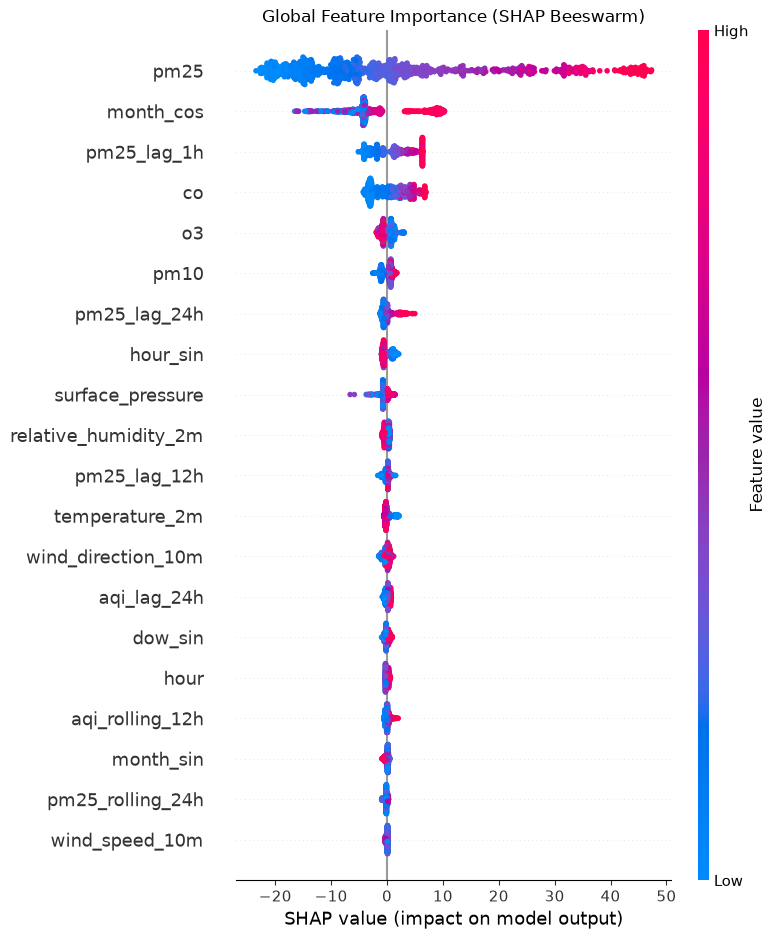

In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title('Global Feature Importance (SHAP Beeswarm)')
plt.tight_layout()
plt.show()

## 2. Local Explanation 
Now, let's explain a *single* prediction. If the AQI is predicted to be severe today, who is to blame? We use a waterfall plot to break down the exact contribution of each feature for a specific hour.

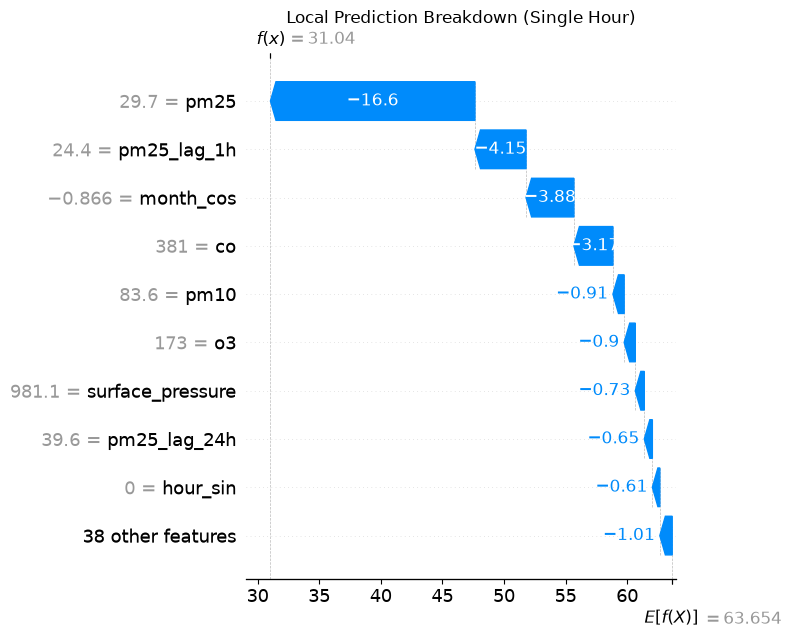

In [3]:
# Explain the very first prediction in our sample
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title('Local Prediction Breakdown (Single Hour)')
plt.tight_layout()
plt.show()